# Prediksi Muka Air Tanah Satu Minggu ke Depan
## 01 — Problem Identification dan Data Understanding

**Studi kasus:** Drenthe, Belanda · **Proyek akhir:** Bootcamp Machine Learning & AI DQLab · **Penyusun:** Raden Satrio Hibatull Rasendriyo

Notebook ini menjelaskan masalah yang ingin saya jawab, data yang dipakai, dan proses menyiapkan data harian menjadi mingguan. Fokusnya belum mencari model terbaik. Sebelum masuk ke sana, saya perlu memastikan arti variabel, tanggal yang hilang, dan aturan pengolahan datanya sudah jelas.

**Alur notebook:** rumusan masalah → mengenal sumber data → memeriksa kualitas → menggabungkan data → agregasi mingguan → pemeriksaan hasil → menyimpan data olahan.

### Cara menjalankan

1. Simpan notebook ini di folder `notebooks` dalam proyek `groundwater_forecasting`.
2. Pastikan `heads_full.csv` dan `input_data.csv` tersedia di `data/raw`. Boleh di dalam satu subfolder, asalkan masing-masing nama file hanya muncul sekali.
3. Gunakan kernel Python yang sudah bisa menjalankan pandas dan matplotlib. Tidak perlu mengganti versi Python hanya karena notebook ini dirapikan.
4. Jalankan semua cell kode dari atas ke bawah. Cell terakhir akan menulis ulang dua CSV olahan di `data/processed`, tetapi tidak mengubah file di `data/raw`.

**Catatan revisi:** output kode dikosongkan agar hasil lama tidak tertukar dengan hasil kode yang sudah diperbaiki. Angka acuan pada penjelasan berasal dari hasil pemeriksaan notebook sebelumnya; cocokkan dengan hasil saat dijalankan ulang.


## 1. Problem Identification — sebenarnya ingin menyelesaikan apa?

### 1.1 Latar belakang dan alasan memilih topik

Saya mengambil peminatan geofisika komputasi dan pernah terlibat dalam monitoring geoteknik saat magang. Parameter yang saya temui antara lain curah hujan, piezometer, prisma/pegs, dewatering, dan extensometer. Pengalaman itu menjadi alasan saya memilih proyek yang masih berhubungan dengan data pemantauan, tetapi bisa dikerjakan menggunakan dataset publik.

Pada proyek ini, saya membatasi pembahasan pada air tanah dan cuaca. Saya ingin bergerak dari sekadar menampilkan data historis menuju percobaan memperkirakan kondisi satu minggu berikutnya. Pertanyaan pentingnya bukan hanya “bisa membuat prediksi atau tidak”, tetapi apakah model memberi hasil yang lebih baik dibanding perkiraan sederhana.

Dataset yang dipakai berasal dari Belanda, bukan dari lokasi magang saya. Jadi, hubungan dengan pengalaman magang terletak pada cara membaca data monitoring dan mengolah deret waktu, bukan berarti karakter lokasi atau kondisi geologinya sama.

### 1.2 Pernyataan masalah

**Belum diketahui apakah informasi historis muka air tanah dan cuaca pada dataset ini dapat menghasilkan prediksi rata-rata muka air tanah satu minggu ke depan yang lebih baik daripada menggunakan nilai minggu terakhir.** Selain itu, catatan air tanah tidak tersedia pada semua tanggal, sehingga cara menangani kekosongan data perlu diputuskan sebelum model dibuat.

Ini merupakan masalah yang akan diuji dalam proyek pembelajaran. Saya tidak mengklaim bahwa pengelola lokasi membutuhkan sistem ini atau bahwa dataset menunjukkan keadaan darurat tertentu.

### 1.3 Pertanyaan penelitian

1. Bagaimana kelengkapan dan karakter dasar data air tanah serta cuaca yang tersedia?
2. Bagaimana menyusun data mingguan tanpa menganggap periode tanpa pengamatan sebagai data nyata?
3. Apakah model dengan riwayat air tanah dan cuaca lebih baik daripada baseline untuk prediksi satu minggu ke depan?
4. Apakah penambahan variabel cuaca membantu dibanding model yang hanya menggunakan riwayat air tanah?
5. Bagaimana hasil observasi, prediksi, dan keterbatasannya dapat ditampilkan dalam dashboard yang mudah dibaca?

### 1.4 Tujuan dan hasil yang ditargetkan

| Tujuan | Bukti hasil yang akan dibuat | Tahap |
| --- | --- | --- |
| Memahami sumber dan kualitas data | Kamus variabel, pemeriksaan tanggal, ringkasan celah data | Notebook ini |
| Menyiapkan data analisis | CSV harian gabungan dan CSV mingguan dengan penanda kelayakan | Notebook ini |
| Mencari pola yang relevan | EDA pada data pengembangan dan kandidat fitur historis | Berikutnya |
| Menguji manfaat model | Perbandingan baseline dan model pada pembagian waktu yang sama | Berikutnya |
| Menyajikan hasil | Prototipe dashboard historis, prediksi, evaluasi, dan catatan batasan | Berikutnya |

Proyek tetap menghasilkan pembelajaran yang valid kalau model rumit ternyata tidak mengalahkan baseline. Hasil seperti itu perlu dilaporkan apa adanya, bukan disembunyikan.


## 2. Definisi Prediksi, Batasan, dan Rencana Evaluasi

### 2.1 Apa yang diprediksi?

Jenis tugasnya adalah **regresi deret waktu**: memprediksi angka yang memiliki urutan waktu.

- **Satu baris analisis:** satu minggu kalender, Senin sampai Minggu, diberi label tanggal Minggu.
- **Waktu membuat prediksi:** setelah minggu `t` selesai.
- **Informasi masukan:** riwayat air tanah dan cuaca yang tersedia sampai akhir minggu `t`.
- **Target:** rata-rata hydraulic head pada minggu `t+1`, dalam meter.
- **Contoh:** data sampai Minggu 9 Januari dipakai untuk memperkirakan rata-rata tanggal 10–16 Januari, bukan untuk menebak ulang minggu 3–9 Januari.

Kolom `groundwater_head_m` di notebook ini masih merupakan **observasi pada minggu yang bersangkutan**. Target minggu berikutnya baru dibuat pada tahap feature engineering. Artinya, tabel mingguan belum langsung menjadi tabel siap latih.

### 2.2 Batasan penggunaan

Proyek ini merupakan eksperimen prediksi historis pada satu sumur. Data cuaca berupa arsip; ketersediaannya tepat pada waktu prediksi operasional belum diverifikasi. Karena itu, prototipe nantinya belum boleh disebut sistem monitoring real-time yang siap dipakai di lapangan.

Prediksi air tanah juga bukan prediksi longsor. Dataset ini tidak menyediakan keseluruhan informasi geoteknik seperti geometri lereng, sifat material, deformasi, dan operasi dewatering. Model tidak digunakan untuk menetapkan status aman/bahaya, tekanan pori di semua lokasi, atau keputusan pompa. Penerapan ke Indonesia memerlukan data lokal dan pengujian ulang.

### 2.3 Model yang direncanakan

Model dicoba bertahap supaya eksplorasinya tetap bisa dipahami. Daftar ini adalah **rencana**, bukan hasil model yang sudah dilatih.

| Kelompok | Model | Hal yang ingin dipelajari |
| --- | --- | --- |
| Baseline | Persistence | Prediksi minggu depan sama dengan head minggu ini; pembanding utama |
| Baseline | Seasonal naïve, 52 minggu | Membandingkan dengan nilai sekitar satu tahun sebelumnya |
| Linear | Linear Regression | Hubungan linear sebagai model awal |
| Linear | Ridge Regression | Pengaruh regularisasi ketika fitur saling berkaitan |
| Berbasis jarak | K-Nearest Neighbors Regressor | Prediksi dari kondisi historis yang mirip |
| Kernel | Support Vector Regression | Hubungan nonlinear dengan sensitivitas terhadap skala dan parameter |
| Pohon | Decision Tree Regressor | Aturan prediksi sederhana dan risiko overfitting |
| Ensemble | Random Forest Regressor | Gabungan pohon untuk menangkap hubungan nonlinear |
| Ensemble | Gradient Boosting Regressor | Perbaikan kesalahan secara bertahap |
| Neural network | MLP Regressor | Eksperimen jaringan saraf pada data tabular |

Untuk seasonal naïve, target `h(t+1)` diperkirakan dengan `h(t+1−52)`, yaitu `h(t−51)`. Pergeseran dihitung pada kalender mingguan lengkap, bukan setelah baris kosong dibuang. Jika nilai pembanding tidak tersedia, cakupan prediksinya dilaporkan; target tidak diisi hanya agar evaluasi terlihat lengkap.

### 2.4 Bagaimana menentukan model yang lebih baik?

1. Tetapkan batas waktu data pengembangan dan data uji sebelum EDA yang digunakan untuk memilih fitur. Catat tanggal batasnya pada notebook berikutnya. Pemeriksaan kelengkapan di notebook ini bukan proses memilih model.
2. Gunakan data lebih lama untuk pelatihan, lalu periode sesudahnya untuk validasi. Jangan memakai pembagian acak seperti pada data klasifikasi biasa.
3. Pada setiap fold validasi, pastikan tanggal target latihan lebih awal daripada awal periode validasi. Ini penting karena target digeser satu minggu ke depan.
4. Bandingkan model pada tanggal evaluasi yang sama. Jika cakupan berbeda karena lag atau baseline musiman, laporkan jumlah sampel dan hasil pada irisan tanggal yang sama.
5. Gunakan **MAE sebagai metrik utama** dan RMSE sebagai pelengkap. Keduanya bersatuan meter; makin kecil makin baik. R² hanya pelengkap, bukan “persentase akurasi”.
6. Pilih kandidat dan lakukan tuning menggunakan validasi deret waktu pada data pengembangan. Data uji paling akhir hanya dipakai setelah pilihan model serta fitur dikunci.
7. Scaling, imputasi fitur jika diperlukan, dan transformasi yang mempelajari statistik data hanya di-fit pada data latihan dalam tiap fold. Gunakan pipeline, terutama untuk Ridge, KNN, SVR, dan MLP.

Belum ada ambang kesalahan yang disepakati untuk kebutuhan operasional. Jadi, keberhasilan awal dinilai dari evaluasi yang benar, keterulangan hasil, dan perbandingan jujur terhadap baseline—bukan janji skor tertentu. Untuk menjawab manfaat cuaca, bandingkan model head-only dan head+cuaca pada tanggal serta prosedur evaluasi yang sama.


## 3. Data Understanding — Mengenal Data dan Sumbernya

Data diambil dari bagian Netherlands pada **Groundwater Time Series Modelling Challenge**. Paket ini sudah disusun untuk penelitian, bukan dump sensor mentah yang sama sekali belum diproses. Folder `raw` dalam proyek saya berarti “file asli yang diunduh, sebelum saya olah”, bukan bukti bahwa penyedia belum melakukan pengolahan.

| File | Isi | Satu baris mewakili |
| --- | --- | --- |
| `heads_full.csv` | Tanggal dan hydraulic head | Catatan air tanah harian yang tersedia |
| `input_data.csv` | Tanggal dan sembilan variabel cuaca | Satu hari data meteorologi |

Konteks lokasi dan data dijelaskan dalam dokumentasi Netherlands serta publikasi challenge. Data meteorologi menggunakan produk grid E-OBS dan mencakup estimasi evaporasi potensial; jangan menganggap semua variabel berasal dari alat yang terpasang tepat di sumur.

**Sumber yang perlu tetap dicantumkan dalam laporan:**

- [Repositori Groundwater Time Series Modelling Challenge](https://github.com/gwmodeling/challenge)
- [Dokumentasi dataset Netherlands](https://github.com/gwmodeling/challenge/blob/main/data/Netherlands/README.md)
- [Collenteur dkk. (2024), artikel penjelasan challenge](https://doi.org/10.5194/hess-28-5193-2024)
- [Arsip dataset dan kode di Zenodo](https://doi.org/10.5281/zenodo.10438290)

Proyek ini memakai dataset tersebut untuk rancangan prediksi mingguan sendiri, **bukan mereplikasi aturan dan skor challenge**. Khususnya, penggunaan riwayat head sebagai prediktor harus dibedakan dari rancangan challenge asal. Saat publikasi, pertahankan atribusi dan periksa ketentuan lisensi repositori serta sumber data yang terkait.

### 3.1 Kamus variabel

| Kolom asli | Nama dalam proyek | Makna dan satuan data harian | Pengolahan mingguan |
| --- | --- | --- | --- |
| Kolom tanggal | `date` | Tanggal pengamatan | Label tanggal Minggu |
| `head` | `groundwater_head_m` | Hydraulic head, meter terhadap acuan elevasi dataset | Rata-rata, dengan syarat kelengkapan |
| `rr` | `rainfall_mm` | Curah hujan harian, mm | Total satu minggu |
| `tg` | `temperature_mean_c` | Suhu rata-rata harian, °C | Rata-rata |
| `tn` | `temperature_min_c` | Suhu minimum harian, °C | Rata-rata minimum harian |
| `tx` | `temperature_max_c` | Suhu maksimum harian, °C | Rata-rata maksimum harian |
| `pp` | `sea_level_pressure_hpa` | Tekanan udara direduksi ke muka laut, hPa | Rata-rata |
| `hu` | `relative_humidity_pct` | Kelembapan relatif, % | Rata-rata |
| `fg` | `wind_speed_ms` | Kecepatan angin, m/s | Rata-rata |
| `qq` | `global_radiation_wm2` | Radiasi global, W/m² | Rata-rata |
| `et` | `potential_evaporation_mm` | Estimasi evaporasi potensial harian, mm | Total satu minggu |

**Dua hal yang mudah tertukar:** nilai head sekitar 11 meter tidak berarti air berada 11 meter di bawah tanah. Head adalah elevasi terhadap acuan tertentu, bukan langsung kedalaman. Selain itu, rata-rata `temperature_min_c` mingguan bukan suhu paling rendah dalam seminggu; itu rata-rata dari tujuh minimum harian.

### 3.2 Membaca dua file

Kode berikut mencari folder proyek dari lokasi kerja notebook. Jika belum ketemu, kode mencoba lokasi Downloads yang sebelumnya dipakai. `cari_file()` memastikan setiap file hanya ditemukan sekali supaya kita tidak tanpa sengaja membaca versi berbeda. `pd.to_datetime()` mengubah teks tanggal menjadi tipe tanggal yang bisa dihitung selisih dan dikelompokkan.


In [1]:
from pathlib import Path
import pandas as pd

# Cari folder proyek dari lokasi notebook atau folder induknya.
kandidat = [Path.cwd(), *Path.cwd().parents]
lokasi_lama = (Path.home() / "Downloads" / "Rasen_Portofolio"
               / "02_Projects" / "groundwater_forecasting")
kandidat.append(lokasi_lama)
PROJECT_DIR = next((p for p in kandidat if (p / "data" / "raw").is_dir()), None)
if PROJECT_DIR is None:
    raise FileNotFoundError(
        "Folder data/raw belum ditemukan. Buka notebook dari proyek "
        "groundwater_forecasting yang memiliki folder data/raw."
    )

RAW_DIR = PROJECT_DIR / "data" / "raw"

def cari_file(nama):
    hasil = list(RAW_DIR.rglob(nama))

    if len(hasil) == 0:
        raise FileNotFoundError(f"{nama} tidak ditemukan di {RAW_DIR}")

    if len(hasil) > 1:
        raise ValueError(
            f"Ada lebih dari satu {nama}. Periksa file duplikat:\n"
            + "\n".join(str(file) for file in hasil)
        )

    return hasil[0]

# Baca dua file secara terpisah.
gwl = pd.read_csv(cari_file("heads_full.csv"))
cuaca = pd.read_csv(cari_file("input_data.csv"))

# Samakan nama kolom pertama menjadi date.
gwl = gwl.rename(columns={gwl.columns[0]: "date"})
cuaca = cuaca.rename(columns={cuaca.columns[0]: "date"})

# Ubah teks tanggal menjadi tipe datetime.
gwl["date"] = pd.to_datetime(gwl["date"], errors="raise")
cuaca["date"] = pd.to_datetime(cuaca["date"], errors="raise")

print("DATA MUKA AIR TANAH")
print("Jumlah baris dan kolom:", gwl.shape)
print("Periode:", gwl["date"].min(), "sampai", gwl["date"].max())
display(gwl.head())

print("\nDATA CUACA")
print("Jumlah baris dan kolom:", cuaca.shape)
print("Periode:", cuaca["date"].min(), "sampai", cuaca["date"].max())
display(cuaca.head())
# Hentikan proses bila file yang terbaca tidak sesuai struktur yang dibutuhkan.
assert {"date", "head"}.issubset(gwl.columns), "Kolom file air tanah tidak sesuai."
assert {"date", "rr", "tg", "tn", "tx", "pp", "hu", "fg", "qq", "et"}.issubset(cuaca.columns), "Kolom file cuaca tidak sesuai."


DATA MUKA AIR TANAH
Jumlah baris dan kolom: (7223, 2)
Periode: 2000-01-01 00:00:00 sampai 2020-11-27 00:00:00


,date,head
0,2000-01-01,11.24
1,2000-01-02,11.24
2,2000-01-03,11.23
3,2000-01-04,11.26
4,2000-01-05,11.24



DATA CUACA
Jumlah baris dan kolom: (11688, 10)
Periode: 1990-01-01 00:00:00 sampai 2021-12-31 00:00:00


,date,rr,tg,tn,tx,pp,hu,fg,qq,et
0,1990-01-01,0.0,-1.71,-2.45,-1.64,1020.60004,93.06250,2.32,9.0,0.074566
1,1990-01-02,0.0,-0.66,-2.29,-0.24,1022.30000,92.05334,2.13,11.0,0.095090
2,1990-01-03,0.0,0.05,-0.62,0.69,1024.10000,91.48948,3.79,12.0,0.106630
3,1990-01-04,2.5,-0.29,-1.86,1.44,1021.60004,93.49286,3.91,10.0,0.087787
4,1990-01-05,0.0,3.21,1.35,3.84,1023.60004,93.28734,3.72,8.0,0.080110


**Cara membaca hasil:** `shape` menunjukkan jumlah baris dan kolom, sedangkan `head()` hanya menampilkan lima baris pertama, bukan seluruh isi file. Rentang cuaca yang lebih panjang tidak perlu dipaksakan menjadi data target air tanah.

Pada pemeriksaan sebelumnya, catatan air tanah mencakup 1 Januari 2000–27 November 2020, sementara cuaca mencakup 1 Januari 1990–31 Desember 2021. Kode di atas menjadi pengecekan ulang periode file yang benar-benar dipakai.

## 4. Pemeriksaan Kualitas Data

### 4.1 Tipe data, isi kosong, dan urutan tanggal

Ada dua jenis kekosongan yang berbeda. **Sel kosong** berarti barisnya ada tetapi salah satu nilainya tidak ada. **Tanggal tidak tercantum** berarti satu hari sama sekali tidak mempunyai baris. Jadi, hasil “sel kosong = 0” belum membuktikan pengamatan harian lengkap.

Pemeriksaan di bawah juga memastikan satu tanggal hanya muncul sekali. Duplikasi tidak otomatis dihapus karena kita harus memahami dulu apakah itu kesalahan atau beberapa pengamatan pada hari yang sama.


In [2]:
import numpy as np

for nama, tabel in [("Air tanah", gwl), ("Cuaca", cuaca)]:
    if tabel.empty or tabel["date"].isna().any():
        raise ValueError(f"{nama}: tabel kosong atau ada tanggal yang tidak terbaca.")
    if tabel["date"].duplicated().any():
        raise ValueError(f"{nama}: ada tanggal duplikat, periksa sebelum melanjutkan.")
    if not tabel["date"].eq(tabel["date"].dt.normalize()).all():
        raise ValueError(f"{nama}: ada komponen jam; periksa definisi data harian.")
    kolom_nilai = tabel.columns.drop("date")
    for kolom in kolom_nilai:
        tabel[kolom] = pd.to_numeric(tabel[kolom], errors="raise")
    if np.isinf(tabel[kolom_nilai].to_numpy(dtype=float)).any():
        raise ValueError(f"{nama}: terdapat nilai tak hingga.")
    print(f"\nSTRUKTUR {nama.upper()}")
    display(pd.DataFrame({
        "tipe_data": tabel.dtypes.astype(str),
        "jumlah_kosong": tabel.isna().sum(),
        "nilai_unik": tabel.nunique()
    }))



STRUKTUR AIR TANAH


,tipe_data,jumlah_kosong,nilai_unik
date,datetime64[ns],0,7223
head,float64,0,89



STRUKTUR CUACA


,tipe_data,jumlah_kosong,nilai_unik
date,datetime64[ns],0,11688
rr,float64,0,285
tg,float64,0,2687
tn,float64,0,2439
tx,float64,0,3093
pp,float64,0,595
hu,float64,0,6307
fg,float64,0,903
qq,float64,0,335
et,float64,0,11686


In [3]:
# Periksa kelengkapan tanggal di masing-masing dataset.
for nama, tabel in [("Air tanah", gwl), ("Cuaca", cuaca)]:
    tanggal = tabel["date"]
    kalender = pd.date_range(
        start=tanggal.min(),
        end=tanggal.max(),
        freq="D"
    )
    tanggal_hilang = kalender.difference(tanggal.dropna())

    print(f"\n{nama.upper()}")
    print("Sel kosong:", tabel.isna().sum().sum())
    print("Tanggal duplikat:", tanggal.duplicated().sum())
    print("Tanggal berurutan:", tanggal.is_monotonic_increasing)
    print("Tanggal yang tidak tercantum:", len(tanggal_hilang))
    print("Contoh tanggal yang tidak tercantum:")
    print(tanggal_hilang[:5].strftime("%Y-%m-%d").tolist())



AIR TANAH
Sel kosong: 0
Tanggal duplikat: 0
Tanggal berurutan: True
Tanggal yang tidak tercantum: 414
Contoh tanggal yang tidak tercantum:
['2000-11-21', '2000-11-22', '2000-11-23', '2000-11-24', '2000-11-25']

CUACA
Sel kosong: 0
Tanggal duplikat: 0
Tanggal berurutan: True
Tanggal yang tidak tercantum: 0
Contoh tanggal yang tidak tercantum:
[]


**Interpretasi hasil sebelumnya:** kedua file tidak memiliki sel kosong dan tanggal duplikat. Namun, pada rentang pengamatan air tanah terdapat **414 tanggal harian tanpa baris**, sementara cuaca lengkap. Ini contoh kenapa data yang tampak rapi tetap perlu diperiksa sebagai deret waktu.

Data tidak perlu sengaja dibuat kotor supaya proyek terlihat realistis. Tantangannya justru ada pada memahami sumber, menjaga urutan waktu, menangani gap dengan masuk akal, dan menguji kemampuan prediksi pada masa depan.

### 4.2 Mencari letak dan panjang celah pengamatan

`shift(1)` menempatkan tanggal sebelumnya di samping tanggal saat ini. Selisih dua tanggal dikurangi satu menunjukkan berapa hari yang tidak tercatat di antaranya. Misalnya, setelah tanggal 20 langsung muncul tanggal 23: tanggal 21 dan 22 tidak tercatat, jadi ada dua hari hilang.


In [4]:
tanggal = gwl["date"].sort_values().reset_index(drop=True)
tanggal_sebelumnya = tanggal.shift(1)

hari_hilang = (tanggal - tanggal_sebelumnya).dt.days - 1
ada_celah = hari_hilang > 0

ringkasan_celah = pd.DataFrame({
    "awal_tanggal_hilang": (
        tanggal_sebelumnya[ada_celah] + pd.Timedelta(days=1)
    ),
    "akhir_tanggal_hilang": (
        tanggal[ada_celah] - pd.Timedelta(days=1)
    ),
    "jumlah_hari": hari_hilang[ada_celah].astype(int)
}).reset_index(drop=True)

display(ringkasan_celah)
print("Total hari tanpa pengamatan:", ringkasan_celah["jumlah_hari"].sum())


,awal_tanggal_hilang,akhir_tanggal_hilang,jumlah_hari
0,2000-11-21,2000-11-30,10
1,2001-11-30,2001-11-30,1
2,2002-12-10,2003-01-01,23
3,2004-09-22,2004-09-23,2
4,2015-09-11,2016-09-22,378


Total hari tanpa pengamatan: 414


**Acuan dari hasil pemeriksaan sebelumnya:**

| Awal celah | Akhir celah | Hari tanpa pengamatan |
| --- | --- | ---: |
| 2000-11-21 | 2000-11-30 | 10 |
| 2001-11-30 | 2001-11-30 | 1 |
| 2002-12-10 | 2003-01-01 | 23 |
| 2004-09-22 | 2004-09-23 | 2 |
| 2015-09-11 | 2016-09-22 | 378 |
| **Total** | | **414** |

Celah 378 hari tidak saya isi dengan garis interpolasi. Mengisi rentang sepanjang itu akan menghasilkan banyak nilai buatan, padahal perubahan sebenarnya tidak diketahui. Penyebab celah juga belum diketahui, jadi belum bisa disebut akibat sensor rusak atau faktor tertentu.

## 5. Menyiapkan Kalender dan Menggabungkan Data

Saya mempertahankan salinan tabel asli, memperjelas nama kolom, lalu membuat kalender harian lengkap sesuai periode air tanah. Kedua tabel digabung ke kalender menggunakan `left merge`. Dengan cara ini, tanggal yang tidak tercatat tetap terlihat sebagai `NaN`, bukan hilang dari urutan waktu.

`validate="one_to_one"` memastikan penggabungan tidak menggandakan baris karena tanggal ganda. Pengurutan diperlukan karena operasi deret waktu bergantung pada posisi tanggal.

Pada versi sebelumnya, kalender mengikuti tabel cuaca. Hasilnya sama untuk cuaca yang lengkap, tetapi kalender eksplisit lebih aman jika file cuaca suatu saat mempunyai gap.


In [5]:
# Membuat salinan agar data asli tetap tersimpan.
gwl_bersih = gwl.copy()
cuaca_bersih = cuaca.copy()

# Mengganti nama kolom agar lebih mudah dipahami.
gwl_bersih = gwl_bersih.rename(columns={
    "head": "groundwater_head_m"
})

cuaca_bersih = cuaca_bersih.rename(columns={
    "rr": "rainfall_mm",
    "tg": "temperature_mean_c",
    "tn": "temperature_min_c",
    "tx": "temperature_max_c",
    "pp": "sea_level_pressure_hpa",
    "hu": "relative_humidity_pct",
    "fg": "wind_speed_ms",
    "qq": "global_radiation_wm2",
    "et": "potential_evaporation_mm"
})

# Membatasi cuaca sesuai periode pengamatan air tanah.
tanggal_awal = gwl_bersih["date"].min()
tanggal_akhir = gwl_bersih["date"].max()

cuaca_periode = cuaca_bersih[
    cuaca_bersih["date"].between(tanggal_awal, tanggal_akhir)
].copy()

# Buat kalender lengkap, bukan hanya memakai tanggal yang tersedia.
kalender_harian = pd.DataFrame({
    "date": pd.date_range(tanggal_awal, tanggal_akhir, freq="D")
})
data_harian = (
    kalender_harian
    .merge(cuaca_periode, on="date", how="left", validate="one_to_one")
    .merge(gwl_bersih, on="date", how="left", validate="one_to_one")
    .sort_values("date")
    .reset_index(drop=True)
)
assert data_harian["date"].diff().dropna().eq(pd.Timedelta(days=1)).all()

print("Ukuran data harian:", data_harian.shape)
print("Periode:", data_harian["date"].min(), "sampai",
      data_harian["date"].max())

print("\nJumlah nilai kosong:")
print(data_harian.isna().sum())

display(data_harian.head())


Ukuran data harian: (7637, 11)
Periode: 2000-01-01 00:00:00 sampai 2020-11-27 00:00:00

Jumlah nilai kosong:
date                          0
rainfall_mm                   0
temperature_mean_c            0
temperature_min_c             0
temperature_max_c             0
sea_level_pressure_hpa        0
relative_humidity_pct         0
wind_speed_ms                 0
global_radiation_wm2          0
potential_evaporation_mm      0
groundwater_head_m          414
dtype: int64


,date,rainfall_mm,temperature_mean_c,temperature_min_c,temperature_max_c,sea_level_pressure_hpa,relative_humidity_pct,wind_speed_ms,global_radiation_wm2,potential_evaporation_mm,groundwater_head_m
0,2000-01-01,0.000000,4.11,0.96,8.51,1022.80000,94.596300,3.38,14.0,0.144754,11.24
1,2000-01-02,0.000000,6.15,3.23,8.00,1025.70010,93.992600,4.33,10.0,0.110497,11.24
2,2000-01-03,14.900001,8.16,5.32,9.15,1018.20000,93.388890,6.76,8.0,0.094391,11.23
3,2000-01-04,3.600000,4.81,2.24,8.58,1013.30000,94.700005,4.12,10.0,0.106417,11.26
4,2000-01-05,0.000000,3.96,1.81,5.51,1017.60004,90.840004,4.78,36.0,0.371323,11.24


**Yang seharusnya terbaca untuk file sebelumnya:** data harian memiliki 7.637 baris dan 11 kolom, termasuk `date`. Ada 414 nilai kosong pada head. Kekosongan ini bukan kerusakan akibat merge; justru sekarang hari tanpa pengamatan sudah terlihat secara eksplisit.

Pada tahap ini saya tidak membuang outlier secara otomatis. Nilai tinggi atau rendah belum tentu kesalahan. Pemeriksaan lebih lanjut perlu mempertimbangkan konteks dan pola waktu, bukan hanya membuang nilai di luar batas statistik.

## 6. Mengubah Data Harian Menjadi Mingguan

Tujuan proyek adalah prediksi mingguan, sehingga resolusi masukan disesuaikan. Agregasi juga merangkum variasi harian, tetapi ada konsekuensinya: kejadian singkat dapat menjadi kurang terlihat. Karena itu, data harian tetap disimpan.

### 6.1 Aturan agregasi dan kelayakan

- `W-SUN` membentuk minggu yang berakhir hari Minggu. Label 9 Januari 2000 mewakili tanggal 3–9 Januari, bukan hanya pengamatan tanggal 9.
- Hujan dan evaporasi potensial dijumlahkan karena kita ingin total selama seminggu. Penjumlahan menggunakan `min_count=1` agar seminggu yang seluruh datanya kosong tidak dianggap bernilai nol.
- Suhu, kelembapan, tekanan, angin, radiasi, dan head dirata-ratakan.
- `head_obs_count` menghitung jumlah hari dengan head tersedia.
- `weather_obs_count` menghitung hari ketika **semua sembilan variabel cuaca** tersedia, bukan hanya curah hujan.
- `week_valid=True` jika head tersedia minimal 4 hari dan cuaca lengkap 7 hari.

Batas **4 dari 7 hari** merupakan aturan kerja proyek ini, bukan standar universal. Tujuannya menjaga lebih dari separuh minggu memiliki pengamatan. Rata-rata dari 4 hari tetap bisa berbeda dari rata-rata 7 hari penuh; pengaruh aturan ini dapat diuji lagi dengan syarat 7/7 pada tahap eksperimen.

Head pada minggu tidak layak dibuat `NaN`, tetapi baris minggunya tetap disimpan. Ini penting agar lag satu minggu tidak melompat melewati celah panjang. Kita juga belum mengisi nilai target yang kosong.


In [6]:
# Menjadikan tanggal sebagai indeks sementara.
harian_index = data_harian.set_index("date")

# Agregasi variabel cuaca.
cuaca_mingguan = harian_index.resample("W-SUN").agg({
    "rainfall_mm": lambda x: x.sum(min_count=1),
    "temperature_mean_c": "mean",
    "temperature_min_c": "mean",
    "temperature_max_c": "mean",
    "sea_level_pressure_hpa": "mean",
    "relative_humidity_pct": "mean",
    "wind_speed_ms": "mean",
    "global_radiation_wm2": "mean",
    "potential_evaporation_mm": lambda x: x.sum(min_count=1)
})

# Menghitung rata-rata dan jumlah observasi muka air tanah per minggu.
air_tanah_mingguan = (
    harian_index[["groundwater_head_m"]]
    .resample("W-SUN")
    .agg(["mean", "count"])
)

air_tanah_mingguan.columns = [
    "groundwater_head_m",
    "head_obs_count"
]

# Hari cuaca lengkap: seluruh variabel, bukan hanya hujan.
kolom_cuaca = [
    "rainfall_mm", "temperature_mean_c", "temperature_min_c",
    "temperature_max_c", "sea_level_pressure_hpa", "relative_humidity_pct",
    "wind_speed_ms", "global_radiation_wm2", "potential_evaporation_mm"
]
weather_obs_count = (
    harian_index[kolom_cuaca].notna().all(axis=1).astype(int)
    .resample("W-SUN").sum().rename("weather_obs_count")
)

# Menggabungkan hasil agregasi.
data_mingguan = cuaca_mingguan.join([
    air_tanah_mingguan,
    weather_obs_count
])

# Minggu dinilai layak jika:
# 1. Minimal empat pengamatan muka air tanah tersedia.
# 2. Data cuaca tersedia selama tujuh hari.
data_mingguan["week_valid"] = (
    (data_mingguan["head_obs_count"] >= 4)
    & (data_mingguan["weather_obs_count"] == 7)
)

# Observasi head mingguan yang tidak layak dibuat kosong.
# Target h(t+1) belum dibuat di notebook ini.
data_mingguan.loc[
    ~data_mingguan["week_valid"],
    "groundwater_head_m"
] = pd.NA

data_mingguan = data_mingguan.reset_index()

print("Ukuran data mingguan:", data_mingguan.shape)
print("Minggu layak:", data_mingguan["week_valid"].sum())
print("Minggu tidak layak:", (~data_mingguan["week_valid"]).sum())

display(data_mingguan.head())


Ukuran data mingguan: (1092, 14)
Minggu layak: 1031
Minggu tidak layak: 61


,date,rainfall_mm,temperature_mean_c,temperature_min_c,temperature_max_c,sea_level_pressure_hpa,relative_humidity_pct,wind_speed_ms,global_radiation_wm2,potential_evaporation_mm,groundwater_head_m,head_obs_count,weather_obs_count,week_valid
0,2000-01-02,0.000000,5.130000,2.095000,8.255000,1024.250050,94.294450,3.855000,12.000000,0.255251,NaN,2,2,False
1,2000-01-09,23.300001,5.160000,2.552857,7.527143,1017.542880,93.025670,5.037143,19.571429,1.439658,11.238571,7,7,True
2,2000-01-16,0.000000,2.071429,0.051429,3.731428,1028.957149,90.567633,3.971429,22.000000,1.457807,11.212857,7,7,True
3,2000-01-23,10.200000,4.262857,1.965714,5.848571,1022.742857,88.605717,5.694286,25.714286,1.828636,11.221429,7,7,True
4,2000-01-30,27.300000,3.325714,0.882857,5.448571,1016.385749,88.376244,5.925714,28.857143,1.957225,11.224286,7,7,True


### 6.2 Cara membaca hasil agregasi

Acuan hasil sebelumnya adalah **1.092 baris × 14 kolom**, dengan **1.031 minggu layak dan 61 minggu tidak layak**. Jumlah 14 kolom sudah benar: 1 tanggal + 9 cuaca + 1 head + 2 hitungan observasi + 1 penanda kelayakan.

Minggu pertama hanya mencakup dua hari karena periode data dimulai 1 Januari 2000. Minggu terakhir juga tidak penuh karena pengamatan berakhir pada hari Jumat. Artinya, minggu tidak layak tidak selalu disebabkan celah di tengah deret; batas periode juga berpengaruh.

`True` di sini hanya berarti lolos aturan kelengkapan. Itu **bukan** berarti prediksi benar, kualitas sensor pasti sempurna, atau model sudah bagus. Sebanyak 1.031 minggu layak juga belum sama dengan jumlah sampel latihan: pembuatan lag dan target minggu berikutnya masih dapat mengurangi jumlah pasangan data yang bisa dipakai.


In [7]:
# Pemeriksaan konsistensi hasil sebelum disimpan.
assert not data_mingguan["date"].duplicated().any()
assert data_mingguan["date"].diff().dropna().eq(pd.Timedelta(days=7)).all()
assert data_mingguan["head_obs_count"].between(0, 7).all()
assert data_mingguan["weather_obs_count"].between(0, 7).all()
assert data_mingguan.loc[~data_mingguan["week_valid"], "groundwater_head_m"].isna().all()
assert data_mingguan.loc[data_mingguan["week_valid"], "groundwater_head_m"].notna().all()

print("Pemeriksaan kalender dan aturan kelayakan: lolos.")
print("Contoh minggu tidak layak:")
display(data_mingguan.loc[~data_mingguan["week_valid"], [
    "date", "head_obs_count", "weather_obs_count", "week_valid"
]].head(10))


Pemeriksaan kalender dan aturan kelayakan: lolos.
Contoh minggu tidak layak:


,date,head_obs_count,weather_obs_count,week_valid
0,2000-01-02,2,2,False
47,2000-11-26,1,7,False
48,2000-12-03,3,7,False
154,2002-12-15,1,7,False
155,2002-12-22,0,7,False
156,2002-12-29,0,7,False
820,2015-09-20,0,7,False
821,2015-09-27,0,7,False
822,2015-10-04,0,7,False
823,2015-10-11,0,7,False


## 7. Visualisasi Awal dan Statistik Ringkas

### 7.1 Grafik untuk memeriksa bentuk data

Grafik berikut digunakan untuk melihat apakah urutan data masuk akal dan apakah celah pengamatan tetap terlihat. Garis akan terputus pada head yang kosong karena tidak dilakukan interpolasi.

Sumbu horizontal menunjukkan waktu, sumbu vertikal menunjukkan head dalam meter terhadap acuan elevasi dataset. Naiknya garis berarti nilai head meningkat, bukan otomatis menunjukkan kondisi berbahaya. Grafik ini juga belum membuktikan bahwa hujan menyebabkan perubahan tertentu; hubungan tersebut perlu ditelusuri pada EDA.


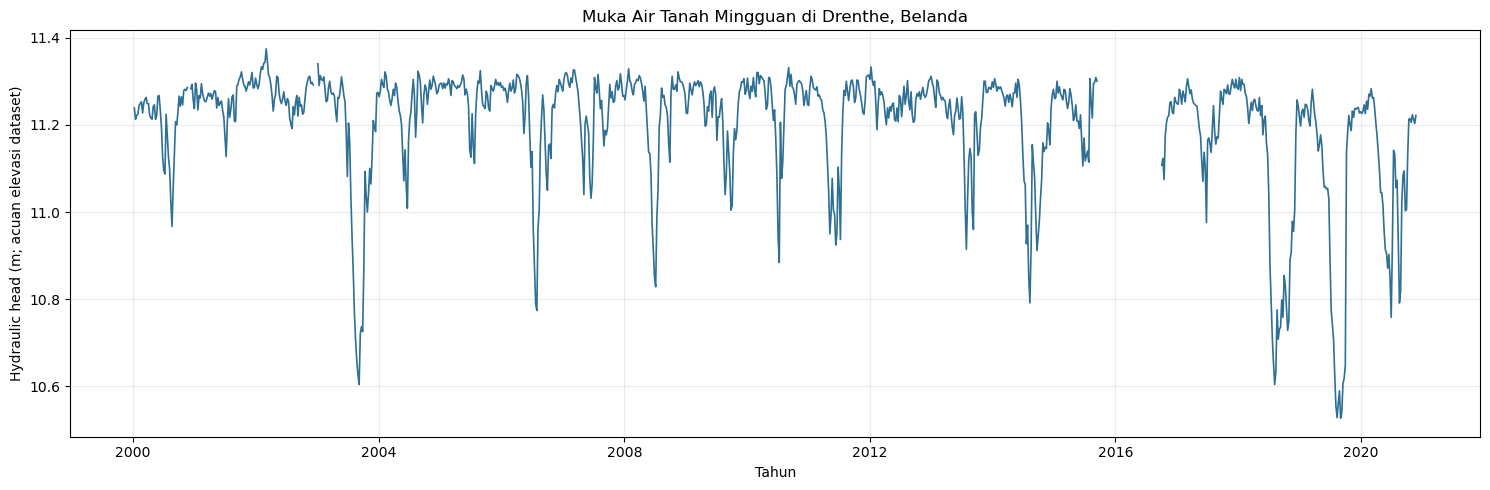

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.plot(
    data_mingguan["date"],
    data_mingguan["groundwater_head_m"],
    color="#2E6F95",
    linewidth=1.2
)

plt.title("Muka Air Tanah Mingguan di Drenthe, Belanda")
plt.xlabel("Tahun")
plt.ylabel("Hydraulic head (m; acuan elevasi dataset)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


### 7.2 Statistik pada minggu yang layak

Statistik dihitung pada baris `week_valid=True` supaya ringkasannya tidak mencampur total hujan dua hari dengan total hujan tujuh hari. Penyaringan ini hanya dipakai untuk tabel deskriptif; tabel kalender utama tidak dibuang barisnya.

`count` adalah jumlah nilai, `mean` rata-rata, `std` ukuran variasi, `min`/`max` nilai terkecil/terbesar, dan `50%` median. Kuartil `25%` serta `75%` membantu membaca rentang tengah data. Angka-angka ini menjelaskan data yang diamati, bukan menilai performa model.

Statistik keseluruhan pada tahap audit ini tidak boleh kemudian dipakai sebagai rata-rata imputasi atau parameter scaling model. Parameter model tetap dihitung dari bagian latihan saja.


In [9]:
kolom_utama = [
    "groundwater_head_m",
    "rainfall_mm",
    "temperature_mean_c",
    "relative_humidity_pct",
    "potential_evaporation_mm"
]

statistik = data_mingguan.loc[data_mingguan["week_valid"], kolom_utama].describe().T.round(3)
display(statistik)


,count,mean,std,min,25%,50%,75%,max
groundwater_head_m,1031.0,11.202,0.141,10.527,11.187,11.253,11.283,11.374
rainfall_mm,1031.0,16.883,15.788,0.000,4.450,13.300,24.450,100.000
temperature_mean_c,1031.0,10.091,5.914,-7.206,5.611,10.246,15.043,24.897
relative_humidity_pct,1031.0,83.109,6.981,53.854,79.260,84.289,88.459,94.042
potential_evaporation_mm,1031.0,10.990,8.396,0.796,2.773,9.612,17.914,32.884


## 8. Menyimpan Hasil Pengolahan

Notebook berikutnya membaca hasil olahan ini agar prosesnya dapat ditelusuri dari sumber yang sama.

| File keluaran | Isi | Kegunaan |
| --- | --- | --- |
| `data/processed/netherlands_daily_merged.csv` | Kalender harian, cuaca, dan head; gap tetap kosong | Audit dan pemeriksaan tingkat harian |
| `data/processed/netherlands_weekly.csv` | Kalender mingguan lengkap, nilai agregat, jumlah observasi, dan `week_valid` | Dasar EDA serta feature engineering |

Cell berikut **menimpa dua file olahan dengan nama yang sama** jika sudah ada. File sumber di `data/raw` tidak diubah. CSV tidak menyimpan tipe tanggal seperti notebook, sehingga saat dibaca lagi gunakan `pd.read_csv(..., parse_dates=["date"])`.


In [10]:
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

file_harian = PROCESSED_DIR / "netherlands_daily_merged.csv"
file_mingguan = PROCESSED_DIR / "netherlands_weekly.csv"

data_harian.to_csv(file_harian, index=False)
data_mingguan.to_csv(file_mingguan, index=False)

print("Data harian tersimpan:", file_harian)
print("Data mingguan tersimpan:", file_mingguan)


Data harian tersimpan: c:\Users\MSI MODERN\Downloads\Rasen_Portofolio\02_Projects\groundwater_forecasting\data\processed\netherlands_daily_merged.csv
Data mingguan tersimpan: c:\Users\MSI MODERN\Downloads\Rasen_Portofolio\02_Projects\groundwater_forecasting\data\processed\netherlands_weekly.csv


## 9. Kesimpulan Data Understanding dan Keputusan Proyek

Berdasarkan hasil pemeriksaan sebelumnya, persoalan utama dataset ini bukan banyaknya sel kosong di CSV, melainkan tanggal pengamatan air tanah yang tidak tercatat. Ada 414 hari tanpa pengamatan dalam lima celah, dengan celah terpanjang 378 hari. Cuaca pada periode yang diperiksa memiliki kalender harian lengkap.

Data disusun menjadi kalender harian dan kemudian mingguan. Dengan aturan minimal empat observasi head dan tujuh hari cuaca lengkap, hasil sebelumnya menunjukkan 1.031 dari 1.092 minggu memenuhi kriteria. Head pada 61 minggu lainnya tetap kosong; kalender tidak dipadatkan.

| Temuan atau keputusan | Alasan | Dampak pada tahap berikutnya |
| --- | --- | --- |
| Gap panjang tidak diinterpolasi | Nilai sebenarnya tidak diketahui | Jangan melatih atau mengevaluasi dengan target buatan |
| Semua minggu tetap disimpan | Jarak waktu harus tetap benar | Buat shift/rolling sebelum menyaring pasangan sampel |
| Cuaca dan head digabung lewat tanggal | Periode sumber berbeda | Gunakan konteks waktu yang sama |
| Head adalah elevasi, bukan kedalaman langsung | Interpretasi fisik harus tepat | Label grafik dan dashboard harus jelas |
| Dataset satu lokasi luar Indonesia | Belum menguji kemampuan lintas lokasi | Hindari klaim siap digunakan di tambang Indonesia |
| Model belum dilatih | Notebook baru sampai persiapan data | Belum ada klaim MAE, RMSE, atau model terbaik |

### 9.1 Langkah berikutnya

1. Pada notebook EDA, tetapkan dan catat batas periode pengembangan serta holdout terakhir terlebih dahulu. Jangan menggunakan holdout untuk memilih fitur atau tuning.
2. Pelajari pola musiman, perubahan head, distribusi variabel, serta dugaan keterlambatan respons pada data pengembangan. Korelasi bukan bukti sebab-akibat.
3. Rancang fitur yang tersedia sampai waktu prediksi, misalnya head terakhir, lag, dan total hujan beberapa minggu sebelumnya. Hindari rolling terpusat yang membaca masa depan.
4. Buat target head minggu depan pada kalender utuh. Setelah fitur dan target tersedia, baru pilih pasangan baris yang memenuhi syarat serta catat berapa sampel yang tersisa.
5. Bangun baseline, lalu bandingkan model secara bertahap. Dashboard dikerjakan setelah alur data dan evaluasi sudah jelas.

**Inti yang perlu saya pahami:** saya belum sedang membuktikan bahwa ML pasti berhasil. Saya sedang menyiapkan percobaan yang adil untuk mengetahui apakah pola historis air tanah dan cuaca memberi prediksi yang berguna dibanding perkiraan sederhana.

### 9.2 Cek pemahaman sebelum lanjut

- Mengapa sel kosong bisa nol, tetapi ada 414 hari tanpa pengamatan?
- Mengapa `week_valid=True` tidak sama dengan “data pasti benar”?
- Mengapa celah 378 hari tidak diisi otomatis?
- Jika memprediksi minggu depan, data sampai tanggal mana yang boleh menjadi input?
- Mengapa model harus dibandingkan dengan persistence?

Jawaban singkatnya: tanggal yang tidak tercatat tidak muncul sebagai sel kosong; `week_valid` hanya aturan kelengkapan; gap panjang tidak mempunyai observasi untuk memastikan hasil isian; input berhenti pada akhir minggu saat prediksi dibuat; dan baseline menguji apakah kerumitan ML memang memberi manfaat.
